# Mathematical exercises

**Exercise 1** (3 points): Problem 4.10 from the PRML textbook.

**Exercise 2** (3 points): Problem 4.16 from the PRML textbook.


# Coding exercises

In the exercises below, we will practice using logistic regression for classification, starting with some low-dimensional synthetic data, then moving on to image classification with real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'x2')

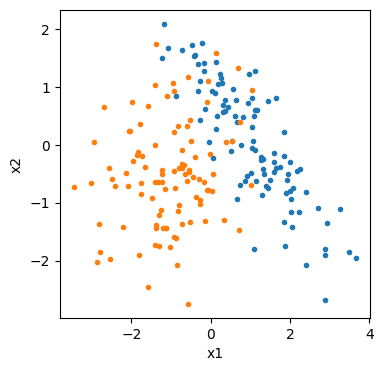

In [2]:
# Make up some two-dimensional data:
nA = 100
muA = np.array([1., 0])
sigA = np.array([[1,-0.8],[-0.8,1]])
xA = np.random.multivariate_normal(muA, sigA, nA)
nB = 100
muB = np.array([-1., -0.5])
sigB = np.array([[1,0.3],[0.3,1]])
xB = np.random.multivariate_normal(muB, sigB, nB)

# Reformat the data:
X = np.vstack((xA, xB))  # X should be n_samples by n_variables, where n_samples=nA+nB
y = np.append(np.zeros(nA), np.ones(nB))  # y should have length n_samples

# Plot the data:
plt.figure(figsize=(4,4))
plt.plot(xA[:,0], xA[:,1], '.')
plt.plot(xB[:,0], xB[:,1], '.')
plt.xlabel('x1')
plt.ylabel('x2')

## Logistic regression with simulated data

## Logistic Regression

**Exercise 1** (5 points): Fit a logistic regression classifier to the synthetic data from above using `LogisticRegression` from the `sklearn` library. Alternatively, you can use `LogisticRegressionCV`, which includes L2 regularization of the weights, with built-in cross-validation to determine the regularization parameter. Report the classification accuracy and plot the result as in the previous exercise, with contours and/or colors denoting the classification probabilities.

### Logistic Regression Model

**Binary Classification:** Given input $\mathbf{x} \in \mathbb{R}^D$, predict probability of class 1:
$$p(\mathcal{C}_1 | \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + w_0) = \frac{1}{1 + \exp(-(\mathbf{w}^T\mathbf{x} + w_0))}$$

where $\sigma(\cdot)$ is the **sigmoid function** and $\mathbf{w} \in \mathbb{R}^D$ are the weights.

**Probability of class 0:**
$$p(\mathcal{C}_0 | \mathbf{x}) = 1 - p(\mathcal{C}_1 | \mathbf{x})$$

**Cross-Entropy Loss (Binary):**
$$E(\mathbf{w}) = -\sum_{n=1}^N \left[ t_n \ln y_n + (1-t_n) \ln(1-y_n) \right]$$

where $t_n \in \{0, 1\}$ is the true label, $y_n = p(\mathcal{C}_1 | \mathbf{x}_n)$ is the predicted probability, and $N$ is the number of samples.

**Gradient for Optimization:**
$$\nabla_{\mathbf{w}} E = \sum_{n=1}^N (y_n - t_n) \mathbf{x}_n$$

**Decision Boundary:** $p(\mathcal{C}_1 | \mathbf{x}) = 0.5 \Rightarrow \mathbf{w}^T\mathbf{x} + w_0 = 0$ (linear boundary in feature space)

In [3]:
from sklearn.linear_model import LogisticRegression

## Solution ##
# Create and fit the model
model = LogisticRegression()
model.fit(X, y)
accuracy = model.score(X, y)
print(f"Classification accuracy: {accuracy:.4f}")

Classification accuracy: 0.9150


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


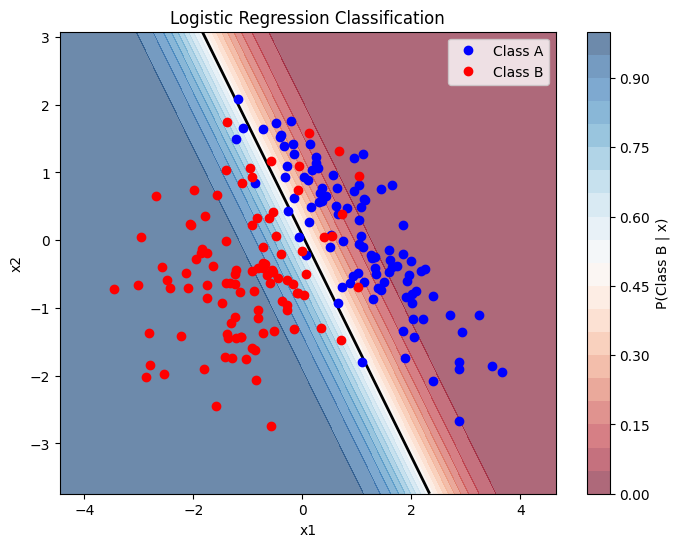

In [4]:
# Create a mesh/grid of points
h = 0.02  # step size in mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Get predicted probabilities for each grid point
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
cf = plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)  # Probability contours
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # Decision boundary

# Overlay the original data
plt.plot(xA[:, 0], xA[:, 1], 'o', color='blue', label='Class A')
plt.plot(xB[:, 0], xB[:, 1], 'o', color='red', label='Class B')

plt.colorbar(cf, label='P(Class B | x)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Classification')
plt.legend()
plt.show()

## Logistic Regression on MNIST

The MNIST dataset is an extremely common dataset for testing algorithms in machine learning. The dataset consists of a large number of handwritten images, where the images are represented by one-dimensional arrays, where each component of the vector represents the grayscale intensity of one image pixel. The images are 28-by-28 pixels, flattened into arrays of length $784=28^2$. The image labels are integers from 0 to 9, representing the identity of each handwritten digit. Below, we will train a classifier with logistic regression to take one of the images as input and predict the identity of the that image.



In [5]:
import numpy as np
import pandas as pd
from scipy.io import arff

# Import the data from local ARFF:
arff_path = "/Users/Haley/Documents/statistical-learning/mnist_784.arff"

raw_data, meta = arff.loadarff(arff_path)
df = pd.DataFrame(raw_data)

# The label column is usually named 'class' in MNIST ARFF files.
label_col = "class" if "class" in df.columns else df.columns[-1]

labels0 = df[label_col].astype(str).astype(int).to_numpy()
images0 = df.drop(columns=[label_col]).to_numpy(dtype=float)

# Look at the labels:
print(labels0[:20])

[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


(70000, 784) (70000,)


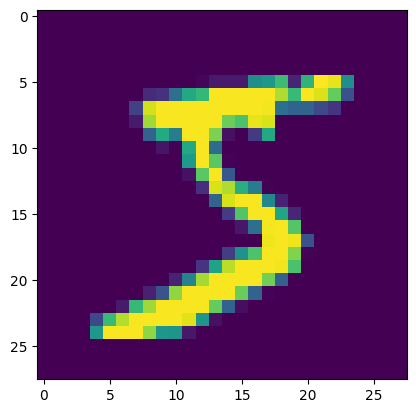

In [18]:
# The size of the full dataset:
print(np.shape(images0), np.shape(labels0)) 

# To speed things up, we'll just use a fraction of the data (feel free to use more if you like):
n_samples = 5000  
images = images0[:n_samples, :] / 255.0   # normalize pixels to [0, 1]
labels = labels0[:n_samples]

# Keep some separate data for testing:
images_test = images0[n_samples:2*n_samples, :] / 255.0   # same normalization on test set
labels_test = labels0[n_samples:2*n_samples]

# To show an example image, reshape the length 784 vector of pixel intensities into a 28x28 matrix:
plt.imshow(np.reshape(images[0,:], (28,28)))


In class, we discussed logistic regression with $K\geq 2$ classes. The probability that an input $\vec{x}$ belongs to class $C_k$ is given by the softmax function:
$$
p(C_k | \vec{x}) = y_k 
= \frac{\exp(\vec{w}_k \cdot \vec{\phi}(\vec{x}))}{\sum_j \exp(\vec{w}_j \cdot \vec{\phi}(\vec{x}))},
$$
and the target label $\vec{t}_n$ for input $\vec{x}_n$ is given by a one-hot vector, i.e. a vector with 1 in the $k$th entry (if the image belongs to class $C_k$) and zeros elsewhere. We showed that the "cross-entropy" error to be minimized is given by
$$
E(\vec{w}_1, \ldots, \vec{w}_K) = -\sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln y_k(\vec{x}_n).
$$
Taking the derivative of this error with respect to $\vec{w}_i$ gave
$$
\frac{\partial E}{\partial \vec{w}_i} = 
-\sum_n \sum_k t_{nk} [\delta_{ki} - y_i(\vec{x}_n)] \vec{\phi}(\vec{x}_n).
$$

**Exercise 2** (5 points): In this exercise we will use the above expressions to implement logistic regression from scratch using only basic Numpy functions. As feature vectors, you can use $\vec{\phi}(\vec{x})=\vec{x}$, or feel free to try different choices to see whether it improves performance. In this exercise, no built-in functions performing logistic regression may be used. First, create one-hot target vectors from the image labels. Next, initialize the weights $\vec{w}_k$ randomly and use the above expressions to update the weights with gradient descent (or, if you prefer, stochastic gradient descent). You will have to use trial and error to choose a learning rate that is small enough to avoid diverging $\vec{w}_k$ but large enough to successfully train in a reasonable number of steps. At each iteration of gradient descent, record the error, then make a plot that shows the error decreasing during training. Once the error has decreased to a small value, freeze the weights, then compute and report the percentage of correct classifications for the images in the testing set. You should be able to obtain testing accuracy of around 70-90%.

Note (Optional): If you're feeling fancy, feel free to try implementing the iterative reweighted least squares algorithm described in Section 4.3.3 of PRML. This algorithm uses second-derivative information in addition to the first derivative shown above. This means that the algorithm should converge in a smaller number of steps than gradient descent, though each step will be more expensive to compute. Another (also optional) thing to try if you're feeling fancy: Include an L2 regularization term for the weights in the error defined above, and see whether this leads to improved performance compared with the model without regularization.

epoch   0 | loss 2.3034
epoch  20 | loss 1.1549
epoch  40 | loss 0.8424
epoch  60 | loss 0.7043


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:36: RuntimeWarning: divide by zero encountered in matmul
  activations = images @ W  # w · phi(x) for all samples
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:36: RuntimeWarning: overflow encountered in matmul
  activations = images @ W  # w · phi(x) for all samples
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:36: RuntimeWarning: invalid value encountered in matmul
  activations = images @ W  # w · phi(x) for all samples
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: divide by zero encountered in matmul
  return (X.T @ (Y - T)) / X.shape[0]
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: overflow encountered in matmul
  return (X.T @ (Y - T)) / X.shape[0]
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: Run

epoch  80 | loss 0.6249
epoch 100 | loss 0.5724
epoch 120 | loss 0.5346
epoch 140 | loss 0.5057
epoch 160 | loss 0.4828
epoch 180 | loss 0.4640


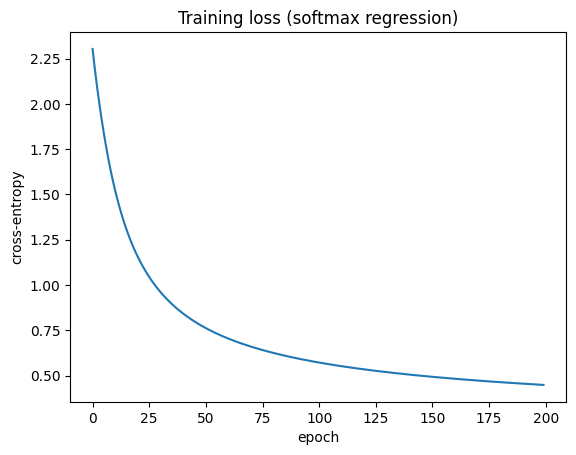

Gradient Descent test accuracy: 87.66%  (after 200 epochs, lr=0.1)


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:53: RuntimeWarning: divide by zero encountered in matmul
  activations_test_gd = images_test @ W
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:53: RuntimeWarning: overflow encountered in matmul
  activations_test_gd = images_test @ W
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:53: RuntimeWarning: invalid value encountered in matmul
  activations_test_gd = images_test @ W


In [7]:
## Solution ##
# create one-hot-encoding
K = 10  # digits 0..9
N, M = images.shape  # N samples, M features (pixels)

# One-hot matrix: shape (N, K)
T = np.zeros((N, K))
T[np.arange(N), labels] = 1

# initialize w randomly
rng = np.random.default_rng() 
W = 0.01 * rng.standard_normal((M, K)) # random number generator from normal 

# softmax turns activations (w · phi(x)) into class probabilities (each row sums to 1)
def softmax(a):
    # subtract max for numerical stability before exponentiating
    a = a - a.max(axis=1, keepdims=True)
    exp_a = np.exp(a)
    return exp_a / exp_a.sum(axis=1, keepdims=True)

# cross-entropy measures how well predicted probabilities match true one-hot labels
def cross_entropy(T, Y):
    return -np.mean(np.sum(T * np.log(Y), axis=1))

# gradient of cross-entropy for softmax regression: X^T(Y - T)
# Y is softmax prediction, T is one-hot true labels, X is input data
def grad_w(X, T, Y):
    return (X.T @ (Y - T)) / X.shape[0]

# train with gradient descent
lr = 0.1
n_epochs = 200
loss_history = []

for epoch in range(n_epochs):
    activations = images @ W  # w · phi(x) for all samples
    Y = softmax(activations)
    loss = cross_entropy(T, Y)
    loss_history.append(loss)

    W -= lr * grad_w(images, T, Y)

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d} | loss {loss:.4f}")

# Plot training loss
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Training loss (softmax regression)")
plt.show()
# Evaluate gradient descent model on test set
activations_test_gd = images_test @ W
Y_test_gd = softmax(activations_test_gd)

preds_gd = np.argmax(Y_test_gd, axis=1)

acc_gd = (preds_gd == labels_test).mean()
print(f"Gradient Descent test accuracy: {acc_gd*100:.2f}%  (after {n_epochs} epochs, lr={lr})")

Original features:    784
Polynomial degree:    4
Transformed features: 3136
epoch   0 | loss 2.2964


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1591105411.py:29: RuntimeWarning: divide by zero encountered in matmul
  Y_phi = softmax(images_phi @ W_phi)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1591105411.py:29: RuntimeWarning: overflow encountered in matmul
  Y_phi = softmax(images_phi @ W_phi)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1591105411.py:29: RuntimeWarning: invalid value encountered in matmul
  Y_phi = softmax(images_phi @ W_phi)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: divide by zero encountered in matmul
  return (X.T @ (Y - T)) / X.shape[0]
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: overflow encountered in matmul
  return (X.T @ (Y - T)) / X.shape[0]
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: invalid value encountered in matmul
  return

epoch  50 | loss 0.4932
epoch 100 | loss 0.3956
epoch 150 | loss 0.3513

With degree-4 phi(x): 89.02%
Without (raw pixels):  87.66%
Difference:            +1.36%


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1591105411.py:37: RuntimeWarning: divide by zero encountered in matmul
  Y_test_phi = softmax(images_test_phi @ W_phi)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1591105411.py:37: RuntimeWarning: overflow encountered in matmul
  Y_test_phi = softmax(images_test_phi @ W_phi)
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1591105411.py:37: RuntimeWarning: invalid value encountered in matmul
  Y_test_phi = softmax(images_test_phi @ W_phi)


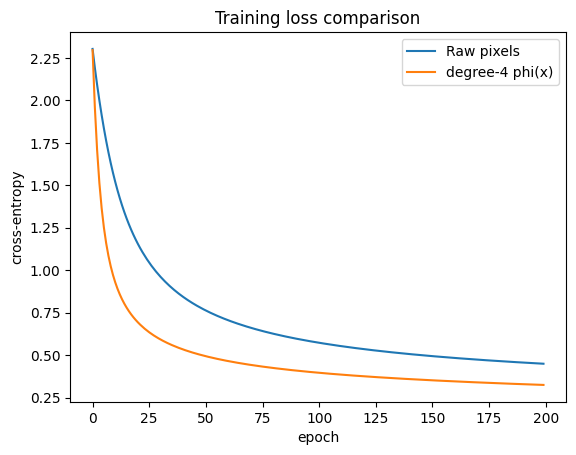

In [8]:
## Trying feature functions for phi(x) ##

def phi_poly(X, degree):
    return np.hstack([X**p for p in range(1, degree + 1)])

degree = 4  # this has the highest test accuracy among degrees 2, 3, 4, 5, 6
phi = lambda X: phi_poly(X, degree)

images_phi = phi(images)
images_test_phi = phi(images_test)

print(f"Original features:    {images.shape[1]}")
print(f"Polynomial degree:    {degree}")
print(f"Transformed features: {images_phi.shape[1]}")

# Re-train with new features
K = 10
N_phi, M_phi = images_phi.shape
T = np.zeros((N_phi, K))
T[np.arange(N_phi), labels] = 1

W_phi = 0.01 * np.random.default_rng(42).standard_normal((M_phi, K))

lr = 0.1
n_epochs = 200
loss_history_phi = []

for epoch in range(n_epochs):
    Y_phi = softmax(images_phi @ W_phi)
    loss = cross_entropy(T, Y_phi)
    loss_history_phi.append(loss)
    W_phi -= lr * grad_w(images_phi, T, Y_phi)
    if epoch % 50 == 0:
        print(f"epoch {epoch:3d} | loss {loss:.4f}")

# Evaluate
Y_test_phi = softmax(images_test_phi @ W_phi)
preds_phi = np.argmax(Y_test_phi, axis=1)
acc_phi = (preds_phi == labels_test).mean()

print(f"\nWith degree-{degree} phi(x): {acc_phi*100:.2f}%")
print(f"Without (raw pixels):  {acc_gd*100:.2f}%")
print(f"Difference:            {(acc_phi - acc_gd)*100:+.2f}%")

plt.plot(loss_history, label='Raw pixels')
plt.plot(loss_history_phi, label=f'degree-{degree} phi(x)')
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Training loss comparison")
plt.legend()
plt.show()

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1937128860.py:10: RuntimeWarning: divide by zero encountered in matmul
  activations_l2 = images @ W_l2
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1937128860.py:10: RuntimeWarning: overflow encountered in matmul
  activations_l2 = images @ W_l2
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1937128860.py:10: RuntimeWarning: invalid value encountered in matmul
  activations_l2 = images @ W_l2
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: divide by zero encountered in matmul
  return (X.T @ (Y - T)) / X.shape[0]
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: overflow encountered in matmul
  return (X.T @ (Y - T)) / X.shape[0]
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/4245927319.py:28: RuntimeWarning: invalid value encountered in matmul
  return (X.T @ (Y - T)

epoch   0 | loss 2.3152
epoch  20 | loss 1.1788
epoch  40 | loss 0.8835
epoch  60 | loss 0.7602
epoch  80 | loss 0.6934
epoch 100 | loss 0.6518
epoch 120 | loss 0.6236
epoch 140 | loss 0.6033
epoch 160 | loss 0.5881
epoch 180 | loss 0.5764


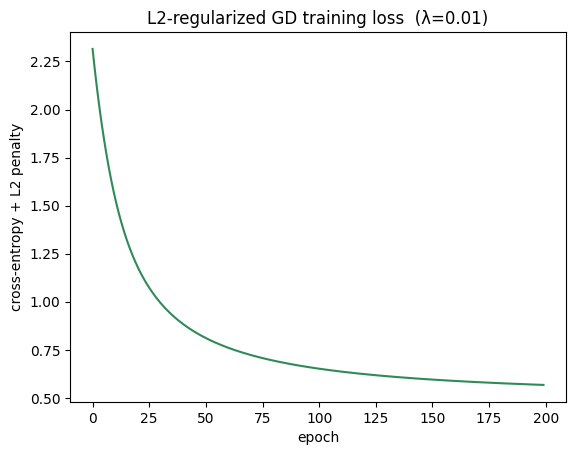

L2-regularized GD test accuracy: 87.58%  (λ=0.01, 200 epochs)
Unregularized GD test accuracy:  87.66%
Difference: -0.08%


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1937128860.py:32: RuntimeWarning: divide by zero encountered in matmul
  activations_test_l2 = images_test @ W_l2
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1937128860.py:32: RuntimeWarning: overflow encountered in matmul
  activations_test_l2 = images_test @ W_l2
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/1937128860.py:32: RuntimeWarning: invalid value encountered in matmul
  activations_test_l2 = images_test @ W_l2


In [ ]:

## Solution - Gradient Descent with L2 Regularization ##

rng3 = np.random.default_rng(0)
W_l2 = 0.01 * rng3.standard_normal((M, K))

lr_l2 = 0.1
lam_l2 = 0.01
loss_history_l2 =[]
for epoch in range(n_epochs):
    activations_l2 = images @ W_l2
    Y_l2 = softmax(activations_l2)

    # Regularized cross-entropy loss
    loss_l2 = cross_entropy(T, Y_l2) + (lam_l2 / 2) * np.sum(W_l2 ** 2)
    loss_history_l2.append(loss_l2)

    # Regularized gradient: standard gradient + λW
    grad = grad_w(images, T, Y_l2) + lam_l2 * W_l2
    W_l2 -= lr_l2 * grad

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d} | loss {loss_l2:.4f}")

# Plot L2 training loss
plt.plot(loss_history_l2, color='seagreen')
plt.xlabel("epoch")
plt.ylabel("cross-entropy + L2 penalty")
plt.title(f"L2-regularized GD training loss  (λ={lam_l2})")
plt.show()

# Evaluate L2-regularized model on test set
activations_test_l2 = images_test @ W_l2
Y_test_l2 = softmax(activations_test_l2)
preds_l2 = np.argmax(Y_test_l2, axis=1)
acc_l2 = (preds_l2 == labels_test).mean()
print(f"L2-regularized GD test accuracy: {acc_l2*100:.2f}%  (λ={lam_l2}, {n_epochs} epochs)")
print(f"Unregularized GD test accuracy:  {acc_gd*100:.2f}%")
print(f"Difference: {(acc_l2 - acc_gd)*100:+.2f}%")


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:14: RuntimeWarning: divide by zero encountered in matmul
  activations_irls = images @ W_irls
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:14: RuntimeWarning: overflow encountered in matmul
  activations_irls = images @ W_irls
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:14: RuntimeWarning: invalid value encountered in matmul
  activations_irls = images @ W_irls
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:31: RuntimeWarning: divide by zero encountered in matmul
  z_k = images @ w_k - (y_k - t_k) / r_k
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:31: RuntimeWarning: overflow encountered in matmul
  z_k = images @ w_k - (y_k - t_k) / r_k
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:31: RuntimeWarning: invalid value encountered in matmul
  z_k = ima

iter   0 | loss 2.3026 | max Δw 5.96e+01
iter   1 | loss 0.4959 | max Δw 2.41e+01
iter   2 | loss 0.2635 | max Δw 1.59e+01
iter   3 | loss 0.1486 | max Δw 1.24e+01
iter   4 | loss 0.0826 | max Δw 1.57e+01
iter   5 | loss 0.0444 | max Δw 1.52e+01
iter   6 | loss 0.0233 | max Δw 1.08e+01
iter   7 | loss 0.0121 | max Δw 1.07e+01
iter   8 | loss 0.0064 | max Δw 9.60e+00
iter   9 | loss 0.0034 | max Δw 8.96e+00
iter  10 | loss 0.0019 | max Δw 8.12e+00
iter  11 | loss 0.0012 | max Δw 6.34e+00
iter  12 | loss 0.0008 | max Δw 5.11e+00
iter  13 | loss 0.0005 | max Δw 3.83e+00
iter  14 | loss 0.0004 | max Δw 2.91e+00
iter  15 | loss 0.0003 | max Δw 2.80e+00
iter  16 | loss 0.0003 | max Δw 2.46e+00
iter  17 | loss 0.0002 | max Δw 1.96e+00
iter  18 | loss 0.0002 | max Δw 1.59e+00
iter  19 | loss 0.0002 | max Δw 1.33e+00

IRLS test accuracy: 84.84%  (converged in 20 iterations)
GD test accuracy:   87.66%  (after 200 epochs)


/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:45: RuntimeWarning: divide by zero encountered in matmul
  activations_test_irls = images_test @ W_irls
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:45: RuntimeWarning: overflow encountered in matmul
  activations_test_irls = images_test @ W_irls
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_37185/555579510.py:45: RuntimeWarning: invalid value encountered in matmul
  activations_test_irls = images_test @ W_irls


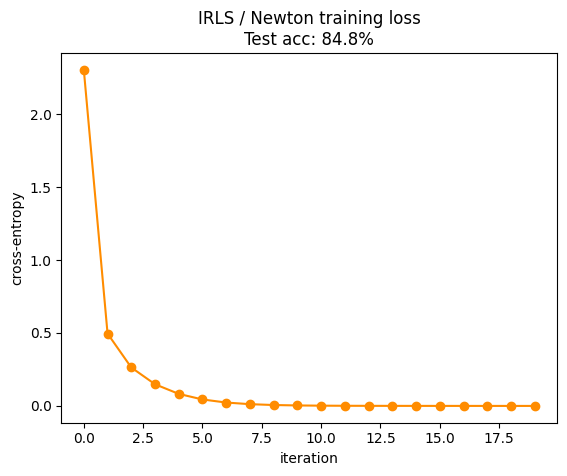

In [11]:
## Solution - IRLS (Iterative Reweighted Least Squares) ##

rng2 = np.random.default_rng()
W_irls = np.zeros((M, K))

tol = 1e-4
max_iter = 20
lam = 1e-4
alpha = 0.5

loss_history_irls = []

for iteration in range(max_iter):
    activations_irls = images @ W_irls
    Y_irls = softmax(activations_irls)

    loss_irls = cross_entropy(T, Y_irls)
    loss_history_irls.append(loss_irls)

    Y_snap = Y_irls.copy()
    W_old  = W_irls.copy()

    for k in range(K):
        y_k = Y_snap[:, k]
        t_k = T[:, k]
        w_k = W_old[:, k]

        r_k = y_k * (1.0 - y_k)
        r_k = np.clip(r_k, 1e-8, None)

        z_k = images @ w_k - (y_k - t_k) / r_k

        Phi_r = images * r_k[:, None]
        H_k   = Phi_r.T @ images + lam * np.eye(M)
        rhs   = Phi_r.T @ z_k
        w_new = np.linalg.solve(H_k, rhs)
        W_irls[:, k] = w_k + alpha * (w_new - w_k)

    max_change = np.max(np.abs(W_irls - W_old))
    print(f"iter {iteration:3d} | loss {loss_irls:.4f} | max Δw {max_change:.2e}")
    if max_change < tol:
        print(f"Converged at iteration {iteration}.")
        break

activations_test_irls = images_test @ W_irls
Y_test_irls = softmax(activations_test_irls)
preds_irls = np.argmax(Y_test_irls, axis=1)
acc_irls = (preds_irls == labels_test).mean()
print(f"\nIRLS test accuracy: {acc_irls*100:.2f}%  (converged in {iteration+1} iterations)")
print(f"GD test accuracy:   {acc_gd*100:.2f}%  (after {n_epochs} epochs)")

plt.plot(loss_history_irls, color='darkorange', marker='o')
plt.xlabel("iteration")
plt.ylabel("cross-entropy")
plt.title(f"IRLS / Newton training loss\nTest acc: {acc_irls*100:.1f}%")
plt.show()

**Exercise 3** (3 points): Repeat the exercise above, now doing things the easy way. Use `LogisticRegression` from the `sklearn` library to perform logistic regression on the MNIST data, then report the percentage of correct classifications using the held-out testing data. If you're feeling fancy (optional) try using L1 and/or L2 regularization or any other tricks you can think of to try to boost the final testing performance.

In [12]:
from sklearn.linear_model import LogisticRegression

## Solution ##
model_mnist = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, multi_class='multinomial')
model_mnist.fit(images, labels)

# Test accuracy
acc_sklearn = model_mnist.score(images_test, labels_test)
print(f"sklearn LogisticRegression test accuracy: {acc_sklearn*100:.2f}%")

print(f"\nComparison:")
print(f"  GD (no regularization):  {acc_gd*100:.2f}%")
print(f"\nWith phi(x) features: {acc_phi*100:.2f}%")
print(f"  GD (L2, λ={lam_l2}):       {acc_l2*100:.2f}%")
print(f"  IRLS:                    {acc_irls*100:.2f}%")
print(f"  sklearn lbfgs (C=1.0):   {acc_sklearn*100:.2f}%")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  r

sklearn LogisticRegression test accuracy: 89.16%

Comparison:
  GD (no regularization):  87.66%

With phi(x) features: 89.02%
  GD (L2, λ=0.01):       87.58%
  IRLS:                    84.84%
  sklearn lbfgs (C=1.0):   89.16%


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


adding polynomial features found to improve text accuracy while IRLS and L2 regularization manually did not improve accuracy. sklearns lbfgs has the highest accuracy likely bc it incorporates bias term and has a more robust solver

**Exercise 4** (6 points): Text classification with logistic regression + confusion matrix + interpretation

In this exercise you will train a **multiclass logistic regression** text classifier on a **real dataset** (20 Newsgroups), evaluate it with a **confusion matrix**, and do a short **error/interpretability analysis** using the learned weights. You are welcome and encouraged to collaborate with an AI on this exercise.

In this exercise, the data are **text documents** (posts) from the 20 Newsgroups dataset, and each document comes with a **known category label**. We train a **multiclass logistic regression** model to classify a *new, unseen document* into one of four topics—`comp.graphics`, `rec.sport.baseball`, `sci.space`, or `talk.politics.misc`—by learning which words (features) are most predictive of each class (i.e., a supervised classification problem; see [computing4all.com](https://computing4all.com/courses/introductory-data-science/lessons/what-is-a-classification-problem/) and [learn.microsoft.com](https://learn.microsoft.com/en-us/training/modules/train-evaluate-classification-models/2-what-is-classification)).

*Dataset*: Use `sklearn.datasets.fetch_20newsgroups` with the following 4 categories (chosen to keep runtime reasonable on laptops):

- `comp.graphics`
- `rec.sport.baseball`
- `sci.space`
- `talk.politics.misc`

Use `remove=("headers","footers","quotes")` to reduce boilerplate.

**(a)** (2 points)
1. Load the dataset (train/test split is provided by `fetch_20newsgroups`).
2. Build a model pipeline:
   - `TfidfVectorizer(stop_words="english", max_features=20000, min_df=2)`
   - `LogisticRegression(...)` (multiclass; choose a solver and `max_iter` so it converges)
3. Fit on the training set.
4. Report **test accuracy**.

**(b)** (2 points)
1. Compute the **confusion matrix** on the test set. Since we haven't seen them in class, you may want to learn about confusion matrices using AI or any of the following references (optional): [github.com](https://github.com/learn-co-curriculum/dsc-confusion-matrices), [github.com](https://github.com/learn-co-curriculum/dsc-visualizing-confusion-matrices-lab), and [carpentries-incubator.github.io](https://carpentries-incubator.github.io/machine-learning-novice-python/06-evaluation/index.html).
2. Plot it (e.g., with `ConfusionMatrixDisplay`).
3. Print **per-class precision/recall/F1** (e.g., `classification_report`).
4. In **2–4 sentences**, interpret at least one notable confusion:
   - Which two classes are most often confused?
   - Is the confusion symmetric or mostly one-directional?
   - What might explain it?

**(c)** (2 points)
Pick **one class** (e.g., `sci.space`) and list the **top 15 words** with the largest weight for that class (highest coefficients).
- Briefly comment (1–3 sentences): do these words make sense for that class?


In [13]:

## Exercise 4 (a) — Load 20 Newsgroups and train a TF-IDF + LogisticRegression pipeline ##
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

categories = ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

# Load train and test splits, strip headers/footers/quotes 
news_train = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers', 'footers', 'quotes'))
news_test  = fetch_20newsgroups(subset='test',  categories=categories,
                                remove=('headers', 'footers', 'quotes'))

print(f"Training documents: {len(news_train.data)}")
print(f"Test documents:     {len(news_test.data)}")
print(f"Classes: {news_train.target_names}")

# Build pipeline: TF-IDF vectorizer → multiclass logistic regression
# splits each doc into individual words, remove meaningless word, discard rare words, keep 20,000 most frequent words 
# outputs how often word appears / number of douments containing word 
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=20000, min_df=2)),
    ('clf',   LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, multi_class='multinomial')),
])

pipeline.fit(news_train.data, news_train.target)

acc_news = pipeline.score(news_test.data, news_test.target)
print(f"\nTest accuracy: {acc_news*100:.2f}%")


Training documents: 2239
Test documents:     1490
Classes: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Test accuracy: 86.51%


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


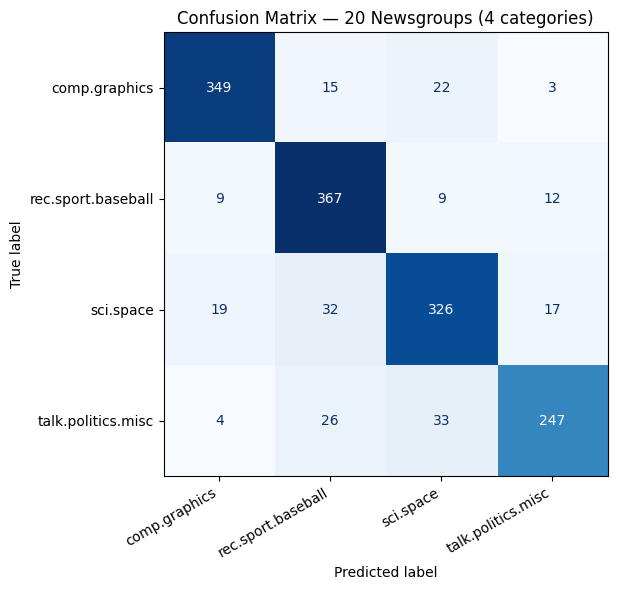

                    precision    recall  f1-score   support

     comp.graphics       0.92      0.90      0.91       389
rec.sport.baseball       0.83      0.92      0.88       397
         sci.space       0.84      0.83      0.83       394
talk.politics.misc       0.89      0.80      0.84       310

          accuracy                           0.87      1490
         macro avg       0.87      0.86      0.86      1490
      weighted avg       0.87      0.87      0.86      1490



In [14]:

## Exercise 4 (b) — Confusion matrix + classification report ##
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
# confusion matrix
y_pred = pipeline.predict(news_test.data)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    news_test.target, y_pred,
    display_labels=news_train.target_names,
    ax=ax, colorbar=False, cmap='Blues'
)
plt.title("Confusion Matrix — 20 Newsgroups (4 categories)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Per-class precision, recall, F1
print(classification_report(news_test.target, y_pred,
                             target_names=news_train.target_names))


Space as baseball (32) and politics as space (33) are the highest off-diagonal scores which means their words are most classified incorrectly. It is interesting though that baseball words are rarely reported as space (9), this could be because space words can refer to a lot of different things, and words like 'fly' 'hit' or even 'launch' could get easily mixed up as baseball words. Politics words mistaken as space could make sense too as things like the space race were highly political topics back during the cold war. I think it could depend on where/when these news articles come from.

In [15]:
## Exercise 4 (c) — Top 15 words ##
vectorizer = pipeline.named_steps['tfidf']
clf        = pipeline.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()

class_name = 'talk.politics.misc'
class_idx  = news_train.target_names.index(class_name)

# Coefficients for this class, sorted descending
coefs = clf.coef_[class_idx]
top15_idx   = np.argsort(coefs)[::-1][:15]
top15_words = feature_names[top15_idx]
top15_coefs = coefs[top15_idx]

print(f"Top 15 words for '{class_name}':")
print(f"{'Word':<20} {'Coefficient':>12}")
print("-" * 34)
for word, coef in zip(top15_words, top15_coefs):
    print(f"{word:<20} {coef:>12.4f}")

Top 15 words for 'talk.politics.misc':
Word                  Coefficient
----------------------------------
people                     2.6794
clinton                    2.3739
government                 2.1355
tax                        1.7425
president                  1.5846
state                      1.5473
drugs                      1.5209
men                        1.4973
evidence                   1.3564
trial                      1.3505
law                        1.3126
bush                       1.2779
gay                        1.1872
homosexual                 1.1473
states                     1.1470


After looking it up, 20 Newgroup dataset is from the early 1990s which makes sense why clinton is the second most popular word. 'people' however can be used in all contexts but interestingly it has the highest tf - idf score. It also makes sense why sometimes politics words are confused as space since talk of the space race or other space/technology related politics, though a decade or so after, could still be brought up as a topic of discussion in politics.